# Exposure Time Calculations for Constraining the presence of polarized speckles at the HLC Band-1 Focal Plane

In [1]:
# Package inputs
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np
import proper
import roman_preflight_proper
from corgisim import scene, instrument
from tqdm import tqdm

In [7]:
# USER INPUTS
star_choice = "Beta TrA" # must be in 'starlist'
single_texp = 2. # Seconds
cr_rate = 0 # Keeping zero for purposes of this simulation

In [8]:
# Star dictionaries
starlist = ["Beta Car", "Beta Lib", "Beta TrA", "Gamma Peg"]
bet_car = {"name": r"$\Beta$"+" Carinae", "Vmag": 1.69, "Spectal Type":"A1III"}
bet_lib = {"name": r"$\Beta$"+" Librae", "Vmag": 2.62, "Spectal Type":"B8V"}
bet_tra = {"name": r"$\Beta$"+" Triangulae Australis", "Vmag": 2.85, "Spectal Type":"F1V"}
gam_peg = {"name": r"$\gamma$"+" Pegisae", "Vmag": 2.84, "Spectal Type":"B2IV"}

match star_choice:
    case "Beta Car":
        star_params = bet_car
    case "Beta Lib":
        star_params = bet_lib
    case "Beta TrA":
        star_params = bet_tra
    case "Gamma Peg":
        star_params = gam_peg
    case _:
        raise ValueError(f"star choice '{star_choice}' not in {starlist}")

## Generate the Polarized Scenes for both the 'POL0' and 'POL45' prisms

In [9]:
# Ensure we have the Proper model
roman_preflight_proper.copy_here()

# USER INPUTS
Vmag = star_params["Vmag"]
spectral_type = star_params["Spectal Type"]
cgi_mode = 'excam'
bandpass_corgisim = '1F'
cor_type = 'hlc'
output_dim = 51
rootname = 'hlc_ni_3e-8'
pixscale_mas = 21.8 # mas/pix

# Set up a mask at the IWA
pixscale_rad = pixscale_mas / 1e3 / 206265
pixscale_lamD = 2.4 / 575e-9 * pixscale_rad
array_center = output_dim // 2
mask = np.zeros([output_dim, output_dim])
rad = pixscale_lamD * output_dim / 2
x = np.linspace(-rad, rad, output_dim)
x, y = np.meshgrid(x, x)
r = np.hypot(y, x)
mask[r <= 5] = 1
mask[r <= 3] = 0

# Init scene
host_star_properties = {
    'Vmag': Vmag,
    'spectral_type': spectral_type,
    'magtype': 'vegamag'
}
base_scene = scene.Scene(host_star_properties, point_source_info=None)

# init dms
dm1 = proper.prop_fits_read( roman_preflight_proper.lib_dir + '/examples/'+rootname+'_dm1_v.fits' )
dm2 = proper.prop_fits_read( roman_preflight_proper.lib_dir + '/examples/'+rootname+'_dm2_v.fits' )

# Init instrument
optics_keywords = {
        'cor_type':cor_type,
        'use_errors':2,
        'polaxis':10,
        'output_dim':output_dim,
        'prism':'POL0',
        'use_dm1':1,
        'dm1_v':dm1,
        'use_dm2':1,
        'dm2_v':dm2,
        'use_fpm':1,
        'use_lyot_stop':1,
        'use_field_stop':1
}

# Remember to clear polarized scenes
polarized_scenes = []
for prism in ['POL0', 'POL45']:

    # Swap the wollaston prism
    optics_keywords['prism'] = prism
    print(f"Simulating PSF with prism  = {optics_keywords['prism']}") 
    
    # re-init optics and generate the PSF
    optics = instrument.CorgiOptics(cgi_mode, bandpass_corgisim, optics_keywords=optics_keywords, if_quiet=True)
    sim_scene = optics.get_host_star_psf(base_scene)
    polarized_scenes.append(sim_scene)

sim_scene_Q = polarized_scenes[0]
sim_scene_U = polarized_scenes[1]

Simulating PSF with prism  = POL0
CorgiOptics initialized with proper keywords.
Simulating PSF with prism  = POL45
CorgiOptics initialized with proper keywords.


# Isolate the exposure time that satisfies the conditions for photon counting
According to Nemati 2020, a given photon counted frame subject to some threshold should not have $\geq 10\%$ of the pixels on a frame be counts. The amount of power will be approximately equivalent between the 'POL0' and 'POL45' when observing an unpolarized star, so we can run this experiment on the $I_{0}$ image from 'POL0'.

Below is just a quick-and-dirty determination that operates by integrating over the histogram of a median image (given a certian gain and exposure time) until you hit $90\%$ of the total.

/home/jarenashcraft/corgisim/corgisim/instrument.py:1187: UserWarning: Detector noise will be different for each sub frame in polarimetry mode. For accurate detector image with noise, please generate full frame image.
  warnings.warn('Detector noise will be different for each sub frame in polarimetry mode. For accurate detector image with noise, please generate full frame image.')


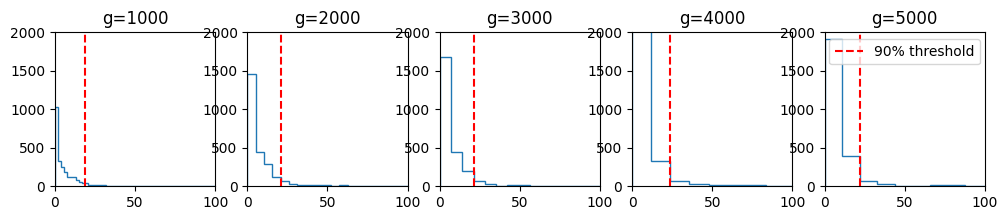

In [10]:
# Need to find the threshold for all gains
gains = np.arange(1_000, 6_000, 1_000)
N_TRIALS = 10
thresholds = []

plt.figure(figsize=[12, 2])
for i, gain in enumerate(gains):

    # Init EMCCD
    emccd_keywords ={'em_gain':gain,
                     'cr_rate':cr_rate}
    detector = instrument.CorgiDetector(emccd_keywords,
                                        photon_counting=False)

    # Generate a small number of EMCCD images to determine a median
    I0 = []
    for trial in range(N_TRIALS):

        # Re-sample scene from flux map
        Q_det = detector.generate_detector_image(sim_scene_Q, single_texp)
        I0.append(Q_det.image_on_detector.data[0].astype(np.float64))

    med_I0 = np.nanmedian(I0, axis=0)

    counts, bins = np.histogram(med_I0, bins=100)

    # Find the 90th percentile bin
    cum_counts = np.cumsum(counts)
    pct_thresh = 0.9 * cum_counts[-1]
    bin_idx = np.searchsorted(cum_counts, pct_thresh)

    threshold_ideal = bins[bin_idx]
    thresholds.append(threshold_ideal)

    plt.subplot(1, len(gains), i+1)
    plt.title(f"g={gain}")
    plt.stairs(counts, bins, alpha=1)
    plt.vlines(threshold_ideal, ymin=0, ymax=3000, linestyle="dashed", color="r", label="90% threshold")
    plt.ylim(0, 2000)
    plt.xlim(0, 100)
plt.legend(loc="upper center")
plt.show()
    
    
    
    

# Performing the Photon Counting Simulations

Running Experment for Different Gains: 0it [00:00, ?it/s]/tmp/ipykernel_63783/1946287690.py:68: RuntimeWarning: invalid value encountered in divide
  q_multiplier = (q_img / DoLP) ** 2
/tmp/ipykernel_63783/1946287690.py:69: RuntimeWarning: invalid value encountered in divide
  u_multiplier = (u_img / DoLP) ** 2
Running Experment for Different Gains: 5it [32:09, 385.99s/it]


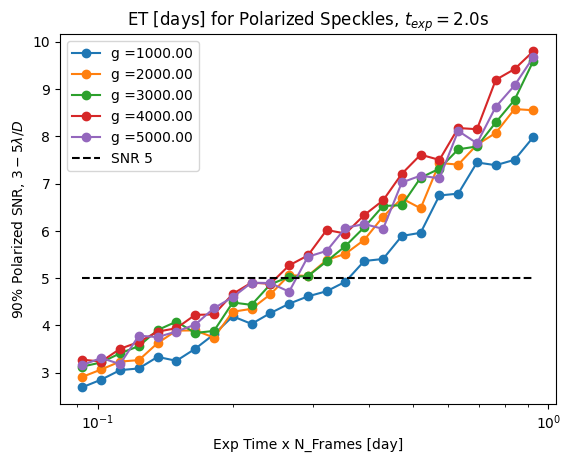

In [11]:
n_frames = np.logspace(2, 3, 25) * 2
s_to_day = 1.15741e-5

# mostly for debugging
plot_intermediates = False


plt.figure()
plt.title("ET [days] for Polarized Speckles, "+r"$t_{exp}=$"+f"{single_texp}s")
for gain, threshold in tqdm(zip(gains, thresholds), desc="Running Experment for Different Gains"):

    mean_Qs = []
    mean_Us = []
    mean_DoLPs = []

    
    # Re-initialize detector
    emccd_keywords ={'em_gain':gain,
                     'cr_rate':cr_rate}
    detector = instrument.CorgiDetector(emccd_keywords,
                                        photon_counting=True)
    
    for N_FRAMES in n_frames:

        N_FRAMES = int(N_FRAMES)

        I0s = []
        I90s = []
        I45s = []
        I135s = []

        for _ in range(N_TRIALS):
            
            # Re-sample scene from flux map
            I0, I90 = detector.generate_photon_counted_detector_image(sim_scene_Q, single_texp, N_FRAMES, threshold=threshold)
            
            # Re-sample scene from flux map
            I45, I135 = detector.generate_photon_counted_detector_image(sim_scene_U, single_texp, N_FRAMES, threshold=threshold)

            I0s.append(I0)
            I90s.append(I90)
            I45s.append(I45)
            I135s.append(I135)

        # Get mean and variance
        I0 = np.nanmedian(I0s, axis=0)
        I90 = np.nanmedian(I90s, axis=0)
        I45 = np.nanmedian(I45s, axis=0)
        I135 = np.nanmedian(I135s, axis=0)

        var_I0 = np.nanvar(I0s, axis=0)
        var_I90 = np.nanvar(I90s, axis=0)
        var_I45 = np.nanvar(I45s, axis=0)
        var_I135 = np.nanvar(I135s, axis=0)
        
        q_img = I0 - I90
        u_img = I45 - I135
        i_img = I0 + I90
    
        # Propagate uncertainty
        var_q = var_I0 + var_I90
        var_u = var_I45 + var_I135
        
        # Compute polarized intensity
        DoLP = np.sqrt(q_img**2 + u_img**2)
        
        # Propagate Uncertainty
        q_multiplier = (q_img / DoLP) ** 2
        u_multiplier = (u_img / DoLP) ** 2
        var_DoLP = q_multiplier * var_q + u_multiplier * var_u
        DoLP /= np.sqrt(var_DoLP)

        # Find max signal in near-IWA annulus
        mean_dolp = np.nanpercentile(DoLP[mask==1], 90)

        # Append to the DoLPs list for plotting
        mean_DoLPs.append(mean_dolp)
    
        if plot_intermediates:

            # Regenerate the working angle patches for plotting
            IWA = Circle([array_center, array_center], radius=3 / pixscale_lamD, edgecolor="w", facecolor="w", alpha=0.5)
            OWA = Circle([array_center, array_center], radius=9 / pixscale_lamD, edgecolor="w", facecolor="None")

            fig, axes = plt.subplots(1, 3, figsize=(12, 4))
            im1 = axes[0].imshow(I0, origin='lower')
            axes[0].set_title(f'0 deg image with noise, hlc \n t = {single_texp * s_to_day}d')
            axes[0].add_patch(IWA)
            axes[0].add_patch(OWA)
            fig.colorbar(im1, ax=axes[0], shrink=0.7)
    
            IWA = Circle([array_center, array_center], radius=3 / pixscale_lamD, edgecolor="w", facecolor="w", alpha=0.5)
            OWA = Circle([array_center, array_center], radius=9 / pixscale_lamD, edgecolor="w", facecolor="None")
            
            im2 = axes[1].imshow(I90, origin='lower')
            axes[1].set_title(f'90 deg image with noise, hlc \n t = {single_texp * s_to_day}d')
            axes[1].add_patch(IWA)
            axes[1].add_patch(OWA)
            fig.colorbar(im2, ax=axes[1], shrink=0.7)

        
            IWA = Circle([array_center, array_center], radius=3 / pixscale_lamD, edgecolor="w", facecolor="w", alpha=0.5)
            OWA = Circle([array_center, array_center], radius=9 / pixscale_lamD, edgecolor="w", facecolor="None")
            
            im3 = axes[2].imshow(DoLP, origin='lower', cmap="Spectral", vmin=1, vmax=9)
            axes[2].set_title('DoLP image, hlc')
            axes[2].add_patch(IWA)
            axes[2].add_patch(OWA)
            fig.colorbar(im3, ax=axes[2], shrink=0.7, label="SNR")
            
            plt.tight_layout()
            plt.show()


    # Begin plotting standard deviation of polarized intensity in annulus
    # Multiply by 2 to account for separate Q and U exposures
    plt.plot(n_frames * s_to_day * 2 * single_texp * N_TRIALS, mean_DoLPs, marker="o", label=f"g ={gain:.2f}")

plt.xscale("log")
plt.xlabel("Exp Time x N_Frames [day]")
plt.ylabel(r"$90\%$"+" Polarized SNR, "+r"$3-5\lambda/D$")
plt.plot(n_frames * s_to_day * 2 * single_texp * N_TRIALS, np.ones_like(mean_DoLPs) * 5, color="k", linestyle="dashed", label="SNR 5")
plt.legend()
plt.show()

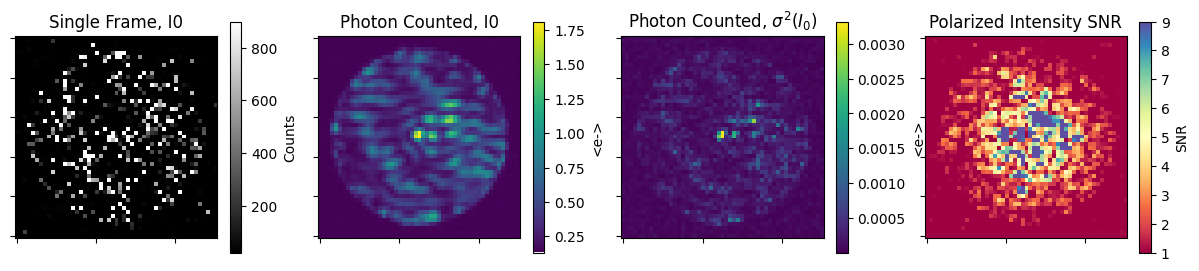

In [12]:
plt.figure(figsize=[15, 3])
plt.subplot(141)
plt.title("Single Frame, I0")
plt.imshow(detector._image_stack_00[0], vmin=thresholds[-1], vmax=900, cmap="gray")
plt.colorbar(label="Counts")
plt.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
plt.tick_params(axis='y', which='both', bottom=True, labelleft=False)
plt.subplot(142)
plt.title("Photon Counted, I0")
plt.imshow(I0, cmap="viridis")
plt.colorbar(label="<e->")
plt.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
plt.tick_params(axis='y', which='both', bottom=True, labelleft=False)
plt.subplot(143)
plt.title("Photon Counted, "+r"$\sigma^2 (I_{0})$")
plt.imshow(var_I0, cmap="viridis")
plt.colorbar(label="<e->")
plt.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
plt.tick_params(axis='y', which='both', bottom=True, labelleft=False)
plt.subplot(144)
plt.title("Polarized Intensity SNR")
plt.imshow(DoLP, cmap="Spectral", vmax=9, vmin=1)
plt.colorbar(label="SNR")
plt.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
plt.tick_params(axis='y', which='both', bottom=True, labelleft=False)
plt.show()

# Plot images for a single case

In [13]:
n_frames

array([ 200.        ,  220.13883425,  242.30553173,  266.70428643,
        293.55985352,  323.11961969,  355.65588201,  391.4683563 ,
        430.88693801,  474.27474113,  522.03144314,  574.59696667,
        632.45553203,  696.14011769,  766.23736991,  843.39300686,
        928.31776672, 1021.7939549 , 1124.68265038, 1237.93163778,
       1362.58413812, 1499.78841866, 1650.80837054, 1817.0351513 ,
       2000.        ])

In [14]:
gain = 5000
texp = 20
nframe = int(n_frames[-1]) #int(n_frames[10]) + 1 # single frame

# Init (and later clear) the stacks of images
I0 = []
I90 = []
I45 = []
I135 = []

for n in tqdm(range(nframe), desc=f"Running Single Observation g={gain}, t={texp}"):

    # Re-initialize detector
    emccd_keywords ={'em_gain':gain,
                     'cr_rate':cr_rate}
    detector = instrument.CorgiDetector(emccd_keywords,
                                        photon_counting=False)

    # Re-sample scene from flux map
    sim_scene_Q_det = detector.generate_detector_image(sim_scene_Q, texp)
    sim_scene_U_det = detector.generate_detector_image(sim_scene_U, texp)
    
    image_tot_corgi_sub_0 = sim_scene_Q_det.image_on_detector.data[0].astype(np.float64)
    image_tot_corgi_sub_90 = sim_scene_Q_det.image_on_detector.data[1].astype(np.float64)

    image_tot_corgi_sub_45 = sim_scene_U_det.image_on_detector.data[0].astype(np.float64)
    image_tot_corgi_sub_135 = sim_scene_U_det.image_on_detector.data[1].astype(np.float64)

    I0.append(image_tot_corgi_sub_0)
    I90.append(image_tot_corgi_sub_90)
    I45.append(image_tot_corgi_sub_45)
    I135.append(image_tot_corgi_sub_135)

# Collapse and convert to polarized quantities
med_I0 = np.nanmedian(I0, axis=0)
med_I90 = np.nanmedian(I90, axis=0)
med_I45 = np.nanmedian(I45, axis=0)
med_I135 = np.nanmedian(I135, axis=0)

var_I0 = np.nanvar(I0, axis=0)
var_I90 = np.nanvar(I90, axis=0)
var_I45 = np.nanvar(I45, axis=0)
var_I135 = np.nanvar(I135, axis=0)

med_Q = med_I0 - med_I90
var_Q = var_I0 + var_I90

med_U = med_I45 - med_I135
var_U = var_I45 + var_I135

med_DoLP = np.sqrt(med_Q**2 + med_U**2)

Q_scaling = (med_Q / med_DoLP) ** 2
U_scaling = (med_U / med_DoLP) ** 2
var_DoLP = Q_scaling * var_Q + U_scaling * var_U

Running Single Observation g=5000, t=20: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:09<00:00, 208.14it/s]
/tmp/ipykernel_63783/123108466.py:53: RuntimeWarning: invalid value encountered in divide
  Q_scaling = (med_Q / med_DoLP) ** 2
/tmp/ipykernel_63783/123108466.py:54: RuntimeWarning: invalid value encountered in divide
  U_scaling = (med_U / med_DoLP) ** 2


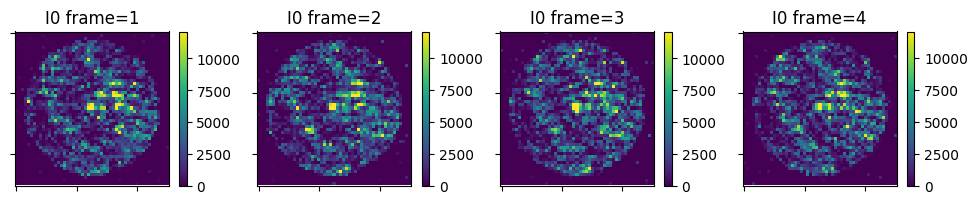

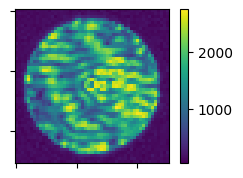

In [64]:
plt.figure(figsize=[12, 2])
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.title(f"I0 frame={i+1}")
    plt.imshow(I0[i])
    plt.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
    plt.tick_params(axis='y', which='both', bottom=True, labelleft=False)
    plt.colorbar()
plt.show()

plt.figure(figsize=[3, 2])
plt.imshow(np.sqrt(var_I0))
plt.colorbar()
plt.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
plt.tick_params(axis='y', which='both', bottom=True, labelleft=False)
plt.show()

NameError: name 'mean_q' is not defined

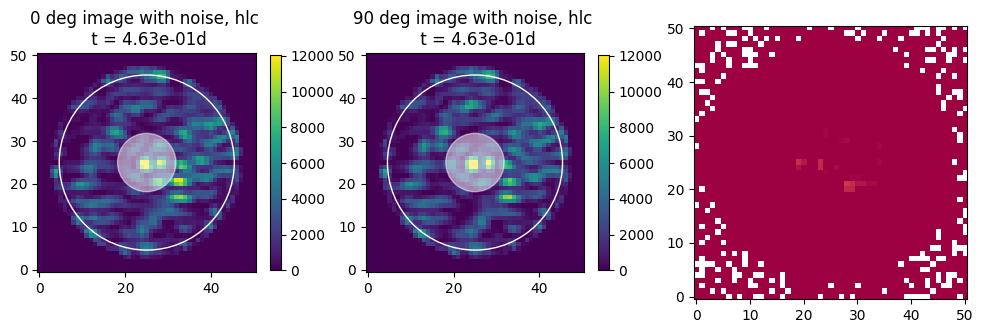

In [65]:
# Regenerate the working angle patches for plotting
IWA = Circle([array_center, array_center], radius=3 / pixscale_lamD, edgecolor="w", facecolor="w", alpha=0.5)
OWA = Circle([array_center, array_center], radius=9 / pixscale_lamD, edgecolor="w", facecolor="None")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
im1 = axes[0].imshow(med_I0, origin='lower')
axes[0].set_title(f'0 deg image with noise, hlc \n t = {texp * nframe * s_to_day * 2:.2e}d')
axes[0].add_patch(IWA)
axes[0].add_patch(OWA)
fig.colorbar(im1, ax=axes[0], shrink=0.7)

IWA = Circle([array_center, array_center], radius=3 / pixscale_lamD, edgecolor="w", facecolor="w", alpha=0.5)
OWA = Circle([array_center, array_center], radius=9 / pixscale_lamD, edgecolor="w", facecolor="None")

im2 = axes[1].imshow(med_I90, origin='lower')
axes[1].set_title(f'90 deg image with noise, hlc \n t = {texp * nframe * s_to_day * 2:.2e}d')
axes[1].add_patch(IWA)
axes[1].add_patch(OWA)
fig.colorbar(im2, ax=axes[1], shrink=0.7)


IWA = Circle([array_center, array_center], radius=3 / pixscale_lamD, edgecolor="w", facecolor="w", alpha=0.5)
OWA = Circle([array_center, array_center], radius=9 / pixscale_lamD, edgecolor="w", facecolor="None")

im3 = axes[2].imshow(med_DoLP / np.sqrt(var_DoLP), origin='lower', cmap="Spectral", vmin=1, vmax=9)
axes[2].set_title('DoLP image, hlc \n' +r'<$q_{counts}$>' + f' ={mean_q}, {mean_q / np.median(i_img):.2e}%')
axes[2].add_patch(IWA)
axes[2].add_patch(OWA)
fig.colorbar(im3, ax=axes[2], shrink=0.7, label="SNR")

plt.tight_layout()
plt.show()

In [ ]:
plt.figure()
plt.subplot(121)
plt.imshow(q_img)
plt.colorbar()
plt.subplot(122)
plt.imshow(u_img)
plt.colorbar()

plt.figure(figsize=[10,3])
plt.subplot(121)
plt.imshow(DoLP / mask, cmap="Spectral")
plt.colorbar(label="Polarized Intensity SNR")
plt.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
plt.tick_params(axis='y', which='both', bottom=True, labelleft=False)
plt.subplot(122)
plt.imshow(np.sqrt(var_DoLP))
plt.colorbar()
plt.show()

In [ ]:
plt.figure(figsize=[10, 4])
space = "    "
plt.suptitle(r"$V_{mag}=$"+f"{Vmag}"+space+r"$t_{exp}=$"+f"{single_texp}s"+space+r"$g=$"+f"{gain}"+space+r"$N_{frames}=$"+f"{N_FRAMES}")
plt.subplot(121)
plt.title("Median"+r"$(I_{90})$")
plt.imshow(np.median(I0, axis=0))
plt.colorbar()
plt.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
plt.tick_params(axis='y', which='both', bottom=True, labelleft=False)

plt.subplot(122)
plt.title(r"$\sigma^2 (I_{90})$")
plt.imshow(np.var(I0, axis=0))
plt.colorbar(label="counts")
plt.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
plt.tick_params(axis='y', which='both', bottom=True, labelleft=False)
plt.show()

In [ ]:
single_texp * N_FRAMES * s_to_day

In [ ]:
plt.imshow(I0[0])

In [ ]:
plt.imshow(DoLP)
plt.colorbar()

In [ ]:
plt.imshow(DoLP / np.sqrt(var_DoLP))
plt.colorbar()

In [ ]:
plt.plot(var_dolps)